# Rotación de Púlsares

La fase de rotación se modela mediante una expansión de Taylor de la frecuencia:

$$\phi(t) = \phi_0 + \left[ F_0 t' + \frac{1}{2}F_1 t'^2 + \frac{1}{6}F_2 t'^3 + \frac{1}{24}F_3 t'^4 \right]$$

donde $t' = t - \text{PEPOCH}$ es el tiempo relativo a la época de referencia, expresado en segundos.

Sus derivadas temporales son:

$$\dot{\phi}(t) = F_0 + F_1 t' + \frac{1}{2}F_2 t'^2 + \frac{1}{6}F_3 t'^3 \quad [\text{Hz}]$$

$$\ddot{\phi}(t) = F_1 + F_2 t' + \frac{1}{2}F_3 t'^2 \quad [\text{Hz/s}]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

---
## 1. Lectura del archivo `.par`

Se parsea el archivo de parámetros y se extraen los valores numéricos.
Las líneas con coordenadas en formato sexagesimal (RAJ, DECJ) se omiten,
ya que no son relevantes para el modelo de rotación.

In [37]:
def leer_par(filename):
    """
    Lee un archivo .par y retorna un diccionario con los parámetros numéricos.
    Incluye el nombre del archivo como clave 'nombre' para identificar el púlsar.
    """
    params = {}

    # Guardar el nombre del archivo (sin extensión) como identificador del púlsar
    params['nombre'] = os.path.splitext(os.path.basename(filename))[0]

    with open(filename, 'r') as f:
        for line in f:
            line = re.sub(r'\\', '', line).strip()  # Eliminar continuaciones de línea de TEMPO2

            if not line or line.startswith('#'):
                continue

            parts = line.split()

            if len(parts) >= 2:
                key = parts[0]
                val_str = parts[1]

                try:
                    if ':' in val_str:  # Omitir RAJ, DECJ
                        continue
                    params[key] = float(val_str)
                except ValueError:
                    pass

    return params

#Funcion optima? para 40 archivos no voy a estar colocando sus 40 nombres...
#Funcion que revise en los archivos del Home, encuentre los .par y los meta en una lista como se hace en archivos_par
def leer_multiples_par(lista_archivos):
    """
    Lee una lista de archivos .par y retorna una lista de diccionarios,
    uno por cada púlsar.

    Parámetros:
        lista_archivos: lista de rutas a archivos .par

    Retorna:
        lista de dicts con los parámetros de cada púlsar
    """
    return [leer_par(f) for f in lista_archivos]


# --- Cargar los archivos .par ---
# Modificar esta lista para incluir los archivos que se deseen analizar.
# Pueden ser 1 o hasta 40+ archivos.
archivos_par = [
    'posg.par',
    'pulsar_2.par',
    'pulsar_3.par',
    "pulsar_4.par",
    "pulsar_5.par"
    #archivos creados por IA, no reales
]

lista_params = leer_multiples_par(archivos_par)

# Mostrar un resumen de los parámetros de rotación de cada púlsar cargado
for p in lista_params:
    print(f"\nPúlsar: {p['nombre']}")
    for k in ['F0', 'F1', 'F2', 'F3', 'PEPOCH']:
        print(f"  {k:10s} = {p.get(k, 'N/A')}")


Púlsar: posg
  F0         = 61.88404726894926
  F1         = -1.9989467063920143e-10
  F2         = 7.810093326935054e-21
  F3         = 0.0
  PEPOCH     = 60379.0

Púlsar: pulsar_2
  F0         = 30.5123456789
  F1         = -5.123456789e-11
  F2         = 1.23456789e-21
  F3         = N/A
  PEPOCH     = 60379.0

Púlsar: pulsar_3
  F0         = 10.123456789
  F1         = -1.23456789e-12
  F2         = 5.678901234e-24
  F3         = N/A
  PEPOCH     = 60379.0

Púlsar: pulsar_4
  F0         = 100.987654321
  F1         = -9.87654321e-11
  F2         = 2.345678901e-21
  F3         = N/A
  PEPOCH     = 60379.0

Púlsar: pulsar_5
  F0         = 5.6789012345
  F1         = -2.345678901e-13
  F2         = 9.87654321e-25
  F3         = N/A
  PEPOCH     = 60379.0


---
## 2. Cálculo de $\dot{\phi}$ y $\ddot{\phi}$ para cada púlsar

Se evalúan ambas derivadas en 500 instantes distribuidos en 30 días a partir de PEPOCH.
El tiempo se expresa en segundos para ser consistente con las unidades de
$F_0$ [Hz], $F_1$ [Hz/s], $F_2$ [Hz/s²] y $F_3$ [Hz/s³].

In [32]:
def calcular_derivadas(params, n_puntos=500, dias=30):
    """
    Calcula phi_dot y phi_ddot para un púlsar dado.

    Parámetros:
        params   : diccionario con los parámetros del púlsar
        n_puntos : número de puntos de evaluación
        dias     : duración del intervalo temporal en días

    Retorna:
        t_dias   : array de tiempos en días
        phi_dot  : array de primera derivada [Hz]
        phi_ddot : array de segunda derivada [Hz/s]
    """
    F0     = params.get('F0',     0.0)
    F1     = params.get('F1',     0.0)
    F2     = params.get('F2',     0.0)
    F3     = params.get('F3',     0.0)
    PEPOCH = params.get('PEPOCH', 0.0)

    # Grilla temporal: desde PEPOCH hasta PEPOCH + dias, convertida a segundos
    t_mjd = np.linspace(PEPOCH, PEPOCH + dias, n_puntos)
    t = (t_mjd - PEPOCH) * 86400.0  # t' en segundos

    # Primera derivada: frecuencia de rotación instantánea [Hz]
    phi_dot = (
        F0
        + F1 * t
        + 0.5 * F2 * t**2
        + (1/6) * F3 * t**3
    )

    # Segunda derivada: tasa de cambio de la frecuencia de rotación [Hz/s]
    phi_ddot = (
        F1
        + F2 * t
        + 0.5 * F3 * t**2
    )

    t_dias = t / 86400.0  # Convertir a días para los ejes
    return t_dias, phi_dot, phi_ddot


# Calcular las derivadas para todos los púlsares cargados
resultados = []
for p in lista_params:
    t_dias, phi_dot, phi_ddot = calcular_derivadas(p)
    resultados.append({
        'nombre'   : p['nombre'],
        't_dias'   : t_dias,
        'phi_dot'  : phi_dot,
        'phi_ddot' : phi_ddot,
    })
    print(f"{p['nombre']}  phi_dot inicial={phi_dot[0]} [Hz]   phi_dot final={phi_dot[-1]} [Hz]")
    print(f"{p['nombre']}  phi_ddot inicial={phi_ddot[0]} [Hz/s]   phi_ddot final={phi_ddot[-1]} [Hz/s]\n")

posg  phi_dot inicial=61.88404726894926 [Hz]   phi_dot final=61.883529168198876 [Hz]
posg  phi_ddot inicial=-1.9989467063920143e-10 [Hz/s]   phi_ddot final=-1.9987442687729802e-10 [Hz/s]

pulsar_2  phi_dot inicial=30.5123456789 [Hz]   phi_dot final=30.51221288304723 [Hz]
pulsar_2  phi_ddot inicial=-5.123456789e-11 [Hz/s]   phi_ddot final=-5.123136789002912e-11 [Hz/s]

pulsar_3  phi_dot inicial=10.123456789 [Hz]   phi_dot final=10.123453589019105 [Hz]
pulsar_3  phi_ddot inicial=-1.23456789e-12 [Hz/s]   phi_ddot final=-1.2345531702880014e-12 [Hz/s]

pulsar_4  phi_dot inicial=100.987654321 [Hz]   phi_dot final=100.98739832887966 [Hz]
pulsar_4  phi_ddot inicial=-9.87654321e-11 [Hz/s]   phi_ddot final=-9.875935210028861e-11 [Hz/s]

pulsar_5  phi_dot inicial=5.6789012345 [Hz]   phi_dot final=5.678900626503346 [Hz]
pulsar_5  phi_ddot inicial=-2.345678901e-13 [Hz/s]   phi_ddot final=-2.3456533009999995e-13 [Hz/s]



---
## 3. Gráficos

Se genera un par de paneles (primera y segunda derivada) por cada púlsar.
Si se cargan múltiples púlsares, cada uno produce su propia figura.

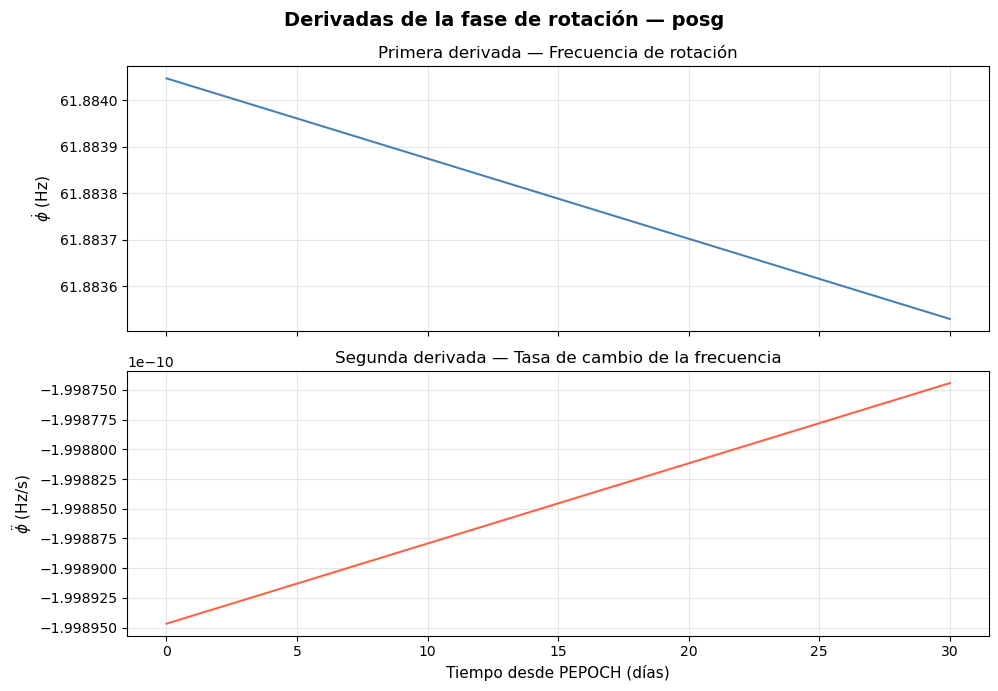

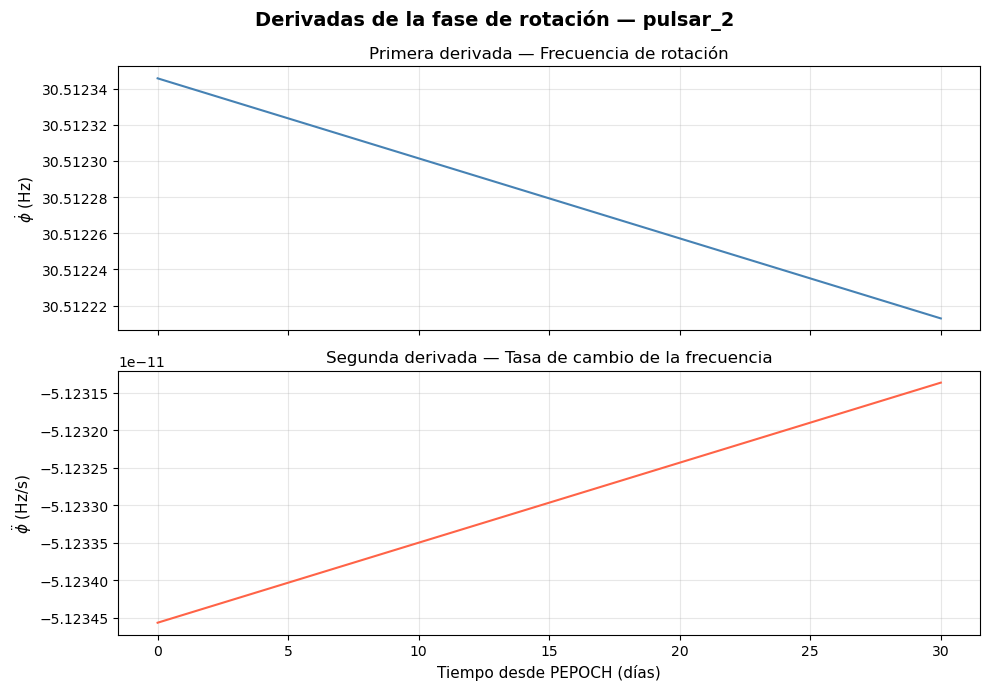

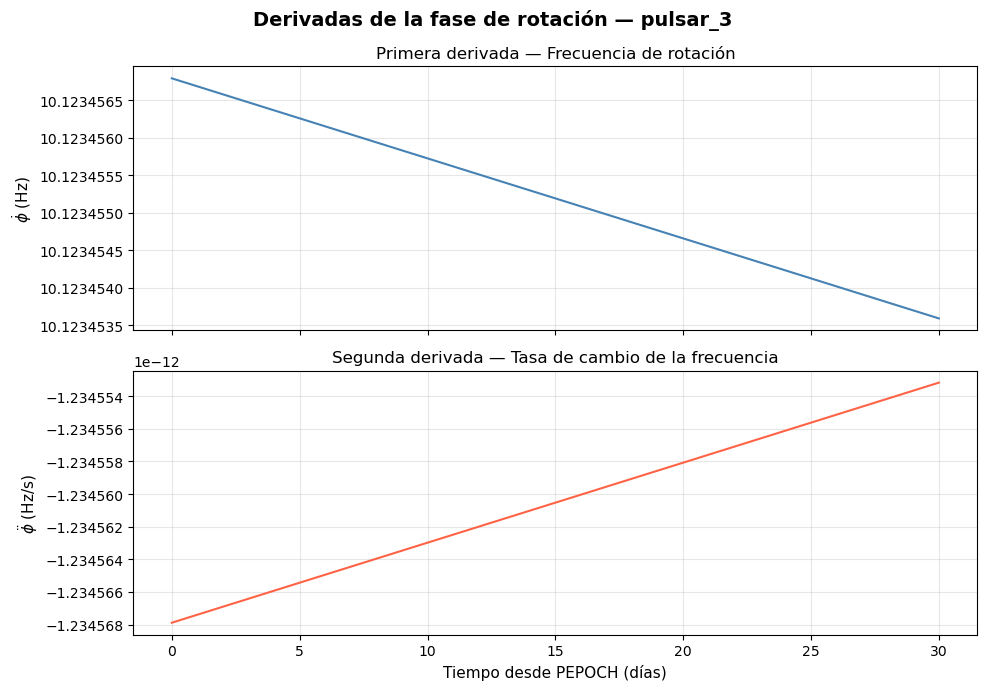

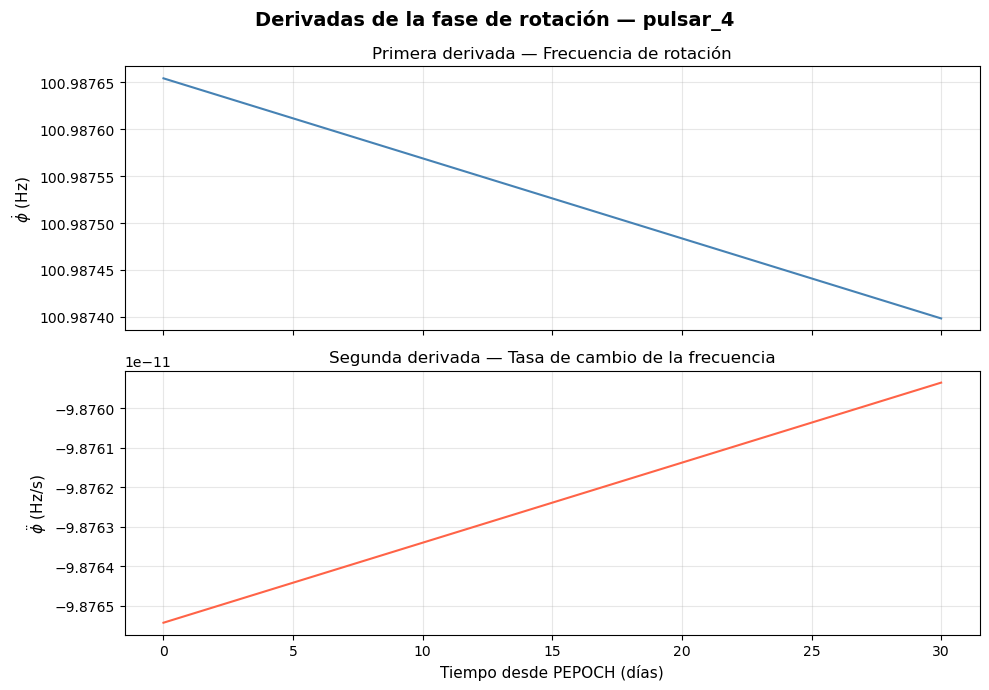

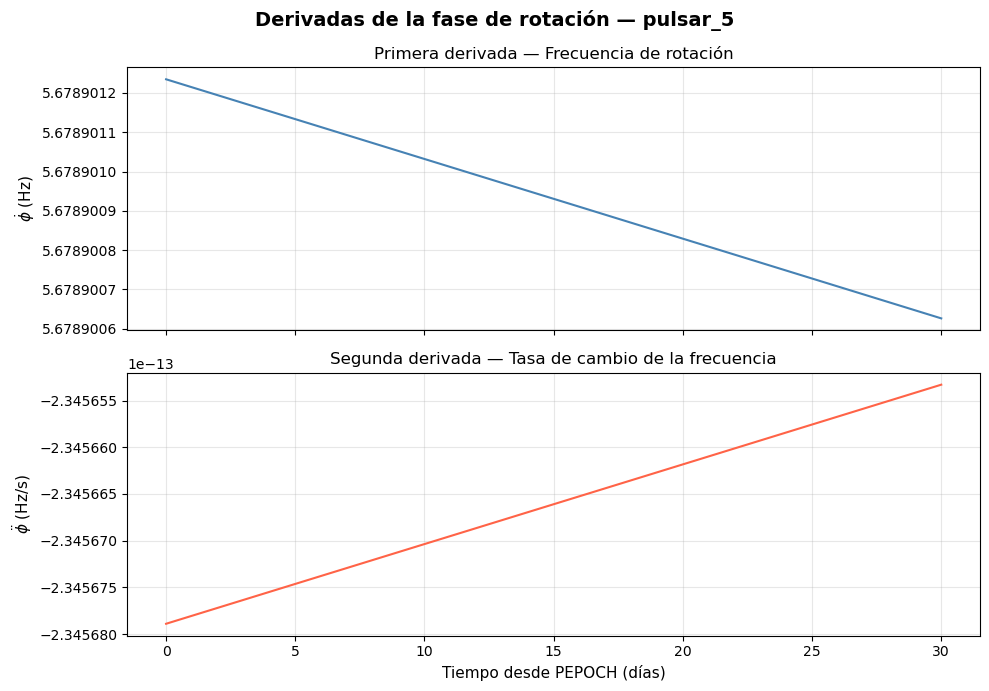

In [33]:
def graficar_pulsar(resultado):
    """
    Genera los gráficos de phi_dot y phi_ddot para un púlsar.
    """
    nombre   = resultado['nombre']
    t_dias   = resultado['t_dias']
    phi_dot  = resultado['phi_dot']
    phi_ddot = resultado['phi_ddot']

    fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    fig.suptitle(f'Derivadas de la fase de rotación — {nombre}',
                 fontsize=14, fontweight='bold')

    # phi_dot: la pendiente negativa refleja el spin-down del púlsar
    axs[0].plot(t_dias, phi_dot, color='steelblue', linewidth=1.5)
    axs[0].set_ylabel(r'$\dot{\phi}$ (Hz)', fontsize=11)
    axs[0].set_title('Primera derivada — Frecuencia de rotación')
    axs[0].ticklabel_format(useOffset=False, style='plain', axis='y')
    axs[0].grid(True, alpha=0.3)

    # phi_ddot: negativa y con leve tendencia creciente por la presencia de F2
    axs[1].plot(t_dias, phi_ddot, color='tomato', linewidth=1.5)
    axs[1].set_ylabel(r'$\ddot{\phi}$ (Hz/s)', fontsize=11)
    axs[1].set_xlabel('Tiempo desde PEPOCH (días)', fontsize=11)
    axs[1].set_title('Segunda derivada — Tasa de cambio de la frecuencia')
    axs[1].ticklabel_format(useOffset=False, style='sci', scilimits=(0,0), axis='y')
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Graficar cada púlsar por separado
for r in resultados:
    graficar_pulsar(r)